In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest

df_cookie = pd.read_csv('data/cookie_cats.csv')


In [51]:
df_cookie.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [52]:
df_cookie.duplicated().sum()

np.int64(0)

In [53]:
df_cookie.count()

userid            90189
version           90189
sum_gamerounds    90189
retention_1       90189
retention_7       90189
dtype: int64

In [54]:
df_cookie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


## Preparing data

In [55]:
df_cookie["retention_7"] = df_cookie["retention_7"].astype(int)

In [56]:
df_cookie.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,0
1,337,gate_30,38,True,0
2,377,gate_40,165,True,0
3,483,gate_40,1,False,0
4,488,gate_40,179,True,1


## Introduction to dataset

Cookie Cats is a mobile game, when a player installs the game, he or she will be randomly assigned to either gate_30 or gate_40 to examine what happens when the first gate (obstacle) in the game was moved from level 30 to level 40.

- userid: A unique number that identifies each player.
- version: Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40).
- sum_gamerounds: the number of game rounds played by the player during the first 14 days after install.
- retention_1: Did the player come back and play 1 day after installing?
- retention_7: Did the player come back and play 7 days after installing?

data source: https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats

research on spending money on free to play games: https://pmc.ncbi.nlm.nih.gov/articles/PMC9737990/#abstract1

The goal of this A/B test is to evaluate the impact of changing the placement of the first difficulty gate in the Cookie Cats mobile game on player engagement and retention.

In the original version of the game, the first gate appears at level 30, while in the experimental version it was moved to level 40. When players installed the game, they were randomly assigned to one of the two groups:

- Control group (gate_30): gate appears at level 30  
- Treatment group (gate_40): gate appears at level 40  

Gates are important game design elements used to regulate player progression and encourage engagement. However, placing a gate too early may frustrate users and lead to churn, while placing it too late may reduce monetization opportunities.

## **Main Goal:** This experiment aims to determine whether moving the gate to a later level improves or harms player retention to provide a data-driven recommendation for game design.

# [An interactive graph with information](https://lookerstudio.google.com/reporting/27696cde-1b50-4c40-80e1-b4eb8cdb46a0)

## Target Metric: 7-Day Retention

**Why retention_7 over retention_1 ?**

Both retention metrics are available, but **7-day retention** is the stronger choice:

- **retention_1** captures whether a player returned the very next day. first impression download, doesn't reveal whether a gate placement creates lasting engagement.
- **retention_7** captures whether a player is still engaged week later. A player that comes back seven days is far more likely to become a pay for premium ingame transaction, making this metric directly tied to revenue and lifetime value.

- Gates are designed to slow progression and encourage purchases. Economic impact accumulates over days — so the metric must look far enough ahead to capture the effect.

For these reasons **retention_7** is the primary target metric.

## **Statistical test selection**

discrete metric ? > large sample size ? > variance known ? > z-test

- **Binary metric**: retention_7 is 0 or 1.
- **Large sample**: ~90,000 users.
- **Two independent groups**: gate_30 (control) vs gate_40 (treatment) with no overlap.
- **Variance**: estimated from data as p(1−p)/n; p ≈ 0.19.

A two-proportion **z-test** is the right call here — it tells us not just whether there's a difference, but which direction it goes, which a chi-square test doesn't give you directly.

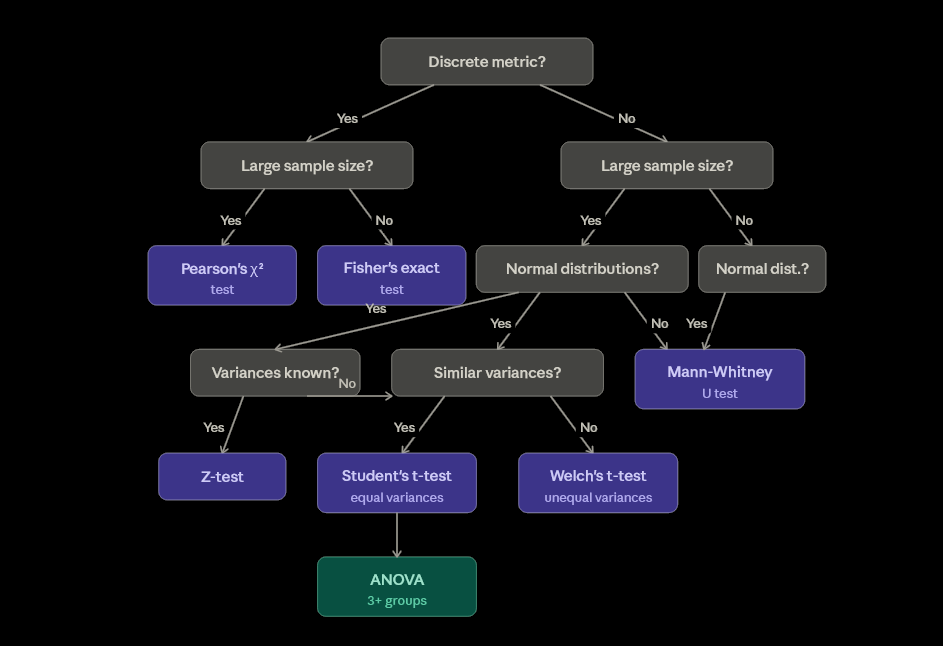

## Number of people that never touched the game after first launch

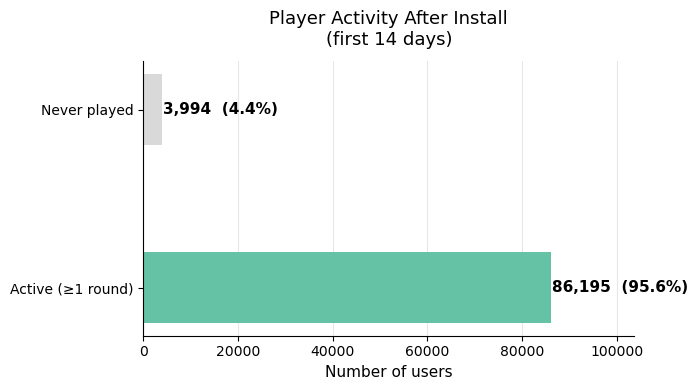

In [57]:
never_played = df_cookie[df_cookie["sum_gamerounds"] == 0]
total = len(df_cookie)
n_never = len(never_played)

active = df_cookie[df_cookie["sum_gamerounds"] > 0]
never  = df_cookie[df_cookie["sum_gamerounds"] == 0]

fig, ax = plt.subplots(figsize=(7, 4))

labels = ["Active (≥1 round)", "Never played"]
sizes  = [len(active), len(never)]
colors = ["#66c2a5", "#d9d9d9"]

bars = ax.barh(labels, sizes, color=colors, height=0.4, zorder=2)

for bar, n in zip(bars, sizes):
    ax.text(n + 200, bar.get_y() + bar.get_height()/2,
            f"{n:,}  ({n/total*100:.1f}%)",
            va="center", fontsize=11, fontweight="bold")

ax.set_title("Player Activity After Install\n(first 14 days)", fontsize=13, pad=12)
ax.set_xlabel("Number of users", fontsize=11)
ax.set_xlim(0, total * 1.15)
ax.grid(axis="x", alpha=0.3, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Sample Size & Variant Proportions

In [58]:
total = len(df_cookie)
counts = df_cookie["version"].value_counts().sort_index()
props = counts / total

print(f"Total users: {total:,}")
print("Group breakdown:")
for version in counts.index:
    print(f"  {version}: n={counts[version]:,}  ({props[version]*100:.1f}% of total)")

print()
summary = df_cookie.groupby("version")["retention_7"].agg(["mean", "count", "sum"])
summary.columns = ["retention_rate", "n", "retained"]
summary["retention_rate_pct"] = summary["retention_rate"] * 100
print(summary[["n", "retained", "retention_rate_pct"]].rename(
    columns={"retention_rate_pct": "retention_rate (%)"}
))

Total users: 90,189
Group breakdown:
  gate_30: n=44,700  (49.6% of total)
  gate_40: n=45,489  (50.4% of total)

             n  retained  retention_rate (%)
version                                     
gate_30  44700      8502           19.020134
gate_40  45489      8279           18.200004


The two groups are close in size (44,700 vs 45,489), representing a near-even 50/50 split as intended. The SRM test below will formally verify this.

Observed 7-day retention rates:
- **gate_30 (control)**: 19.02%
- **gate_40 (treatment)**: 18.20%
- **Raw difference**: −0.82 percentage points (gate_40 − gate_30)

## [SRM (Sample Ratio Mismatch)](https://en.wikipedia.org/wiki/Sample_ratio_mismatch)
*When we run an A/B test, we expect roughly half the users to land in each group. An SRM is when that split is off by more than random chance would explain  for example - you intended 50/50 but got 55/45.
This matters because if the groups aren't balanced the way we designed them to be, something probably went wrong with the randomization. Maybe there's a bug in how users got assigned, or one group had more dropouts. Either way, two groups are no longer comparable, and any difference we measure in retention could be from the imbalance, not the gate change.*

- A/B testing error where the observed number of users in each variant significantly differs from the intended allocation
- example:
    Redirect Issues: In a test where 50% of traffic is sent to a new page, if the redirect takes too long, users may close the browser before reaching it. This results in fewer people in the treatment group, causing an apparent 50/50 split to actually be 55/45

In [59]:
counts = df_cookie["version"].value_counts()
chisquare(counts)

Power_divergenceResult(statistic=np.float64(6.9024049496058275), pvalue=np.float64(0.008607987810836262))

- p = 0.0086 < 0.05

Sample Ratio mismatch detected
A chi-square test was performed to verify whether users were evenly distributed between the control and treatment groups.
Null hypothesis: users are split evenly

- Result: p-value = 0.0086

Since p < 0.05, we reject the null hypothesis.

This indicates a sample ratio mismatch (SRM), meaning the group sizes differ more than expected by random chance.

So while we note the SRM and can't fully rule out a randomization issue, the imbalance is small enough that it's unlikely to meaningfully bias the results. We proceed with the analysis, but keep this caveat in mind when interpreting the findings.

## [Proportion Z-Test](https://en.wikipedia.org/wiki/Two-proportion_Z-test)
*Each user either came back or didn't — that's a binary outcome. We have two independent groups. We want to know if their retention rates are meaningfully different.
The z-test converts the gap between two proportions into a single number (the z-score) and asks: how unlikely is this gap if there's actually no difference? If unlikely enough, we call it significant.*

In [60]:
success = summary["retained"].values
nobs = summary["n"].values

z_stat, p_value = proportions_ztest(success, nobs)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.5f}")

Z-statistic: 3.1644
P-value: 0.00155


- Z-test p-value: 0.00155
- Bootstrap CI: [-1.31%, -0.30%]

The p-value is below 0.05 = statistically significant

The confidence interval does not include 0 = consistent result

## [Confidence Intervals:](https://en.wikipedia.org/wiki/Confidence_interval) Analytical vs Bootstrap

*Confidence interval is a statistical measure used to indicate the range of estimates within which an unknown statistical parameter is likely to fall. A good confident answer is usually above 95%*

*Analytical — uses a formula. Fast, assumes the data is roughly normally distributed.*

*Bootstrap — resamples your data 10,000 times and builds the interval from the actual distribution of results. No assumptions, just brute force.*

In [61]:
boot_diffs = []

for _ in range(10000):
    sample = df_cookie.sample(frac=1, replace=True)
    
    grp = sample.groupby("version")["retention_7"].mean()
    
    diff = grp["gate_40"] - grp["gate_30"]
    boot_diffs.append(diff)

ci = np.percentile(boot_diffs, [2.5, 97.5])
print(ci)

[-0.01324467 -0.00311385]


In [62]:
p30 = summary.loc["gate_30", "retention_rate"]
n30 = int(summary.loc["gate_30", "n"])
p40 = summary.loc["gate_40", "retention_rate"]
n40 = int(summary.loc["gate_40", "n"])

effect = p40 - p30
print(f"Treatment effect (gate_40 − gate_30): {effect*100:.4f} percentage points")

Treatment effect (gate_40 − gate_30): -0.8201 percentage points


### Analytical Confidence Interval (Normal Approximation)

Using the standard error of the difference between two proportions:

**95% Confidence Interval** = effect ± 1.96 × SE ≈ **[−1.31%, −0.33%]**

This approach assumes the sampling distribution of the difference is approximately normal — valid here given n ≈ 90,000 and p ≈ 0.19.

### Bootstrap Confidence Interval (Percentile Method)

10,000 resamples with replacement, computing the difference in group means each time.

**95% Bootstrap Confidence Interval** ≈ **[−1.31%, −0.30%]**

### Comparison:
- Analytical (normal) Lower bound −1.31% Upper bound −0.33%
- Bootstrap (percentile) Lower bound −1.31% Upper bound −0.30%

The two intervals are nearly identical — expected given the large sample size, where the central limit theorem makes the normal approximation very accurate. Both intervals lie **entirely below zero**, confirming a statistically significant negative effect.

### [Bootstrap CI](https://acclab.github.io/bootstrap-confidence-intervals.html)

10,000 resamples with replacement.

**95% Bootstrap Confidence Interval** = **[−1.31%, −0.30%]**

See the comparison table and visualization below.

In [63]:
p30 = summary.loc["gate_30", "retention_rate"]
n30 = int(summary.loc["gate_30", "n"])
p40 = summary.loc["gate_40", "retention_rate"]
n40 = int(summary.loc["gate_40", "n"])

effect = p40 - p30
print(f"Treatment effect (gate_40 − gate_30): {effect*100:.4f} percentage points")

Treatment effect (gate_40 − gate_30): -0.8201 percentage points


The treatment effect is **−0.82 percentage points** (gate_40 retains worse than gate_30).

The negative sign matters: gate_40 is the *worse* variant.

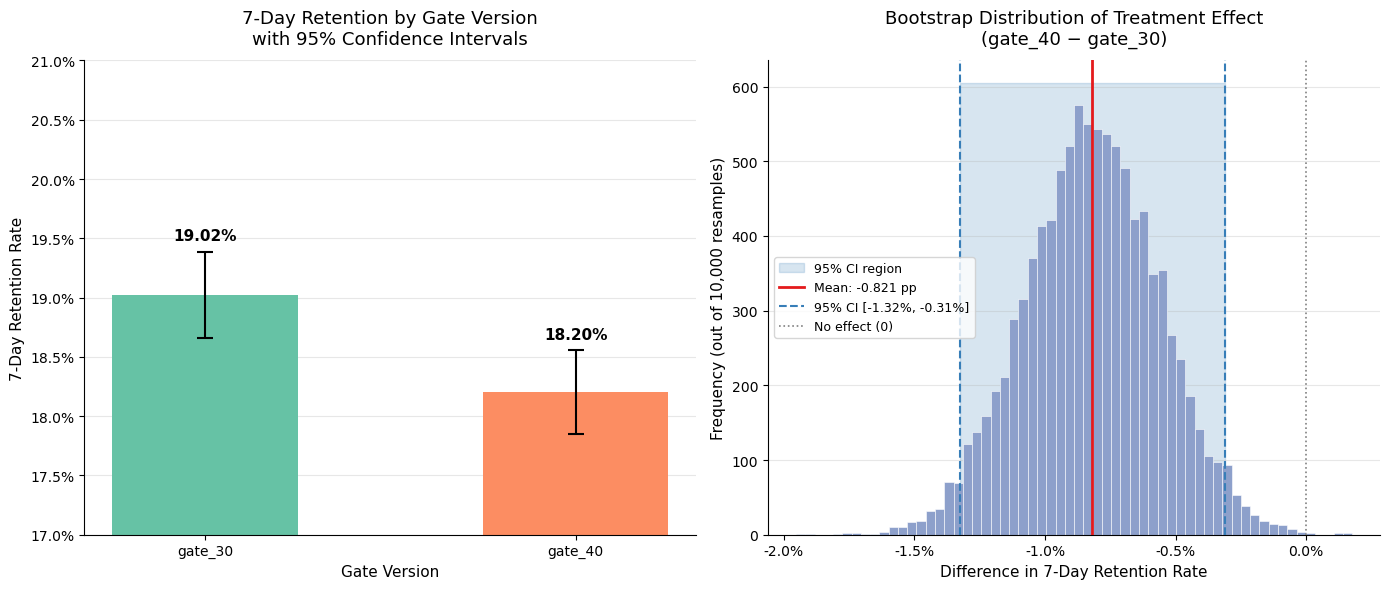

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

'Bar chart with per-group 95% CIs — error bars computed from the normal approximation'
ax1.bar(["gate_30", "gate_40"], [p30, p40], color=["#66c2a5", "#fc8d62"], width=0.5, zorder=2)

se30 = np.sqrt(p30 * (1 - p30) / n30)
se40 = np.sqrt(p40 * (1 - p40) / n40)

ax1.errorbar([0, 1], [p30, p40],
             yerr=[[1.96*se30, 1.96*se40], [1.96*se30, 1.96*se40]],
             fmt="none", color="black", capsize=6, capthick=1.5, elinewidth=1.5, zorder=3)

'Labels sit just above the upper error bar so they never overlap the cap'
ax1.text(0, p30 + 1.96*se30 + 0.001, f"{p30*100:.2f}%", ha="center", fontsize=11, fontweight="bold")
ax1.text(1, p40 + 1.96*se40 + 0.001, f"{p40*100:.2f}%", ha="center", fontsize=11, fontweight="bold")

ax1.set_title("7-Day Retention by Gate Version\nwith 95% Confidence Intervals", fontsize=13, pad=12)
ax1.set_xlabel("Gate Version", fontsize=11)
ax1.set_ylabel("7-Day Retention Rate", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax1.set_ylim(0.17, 0.21)
ax1.grid(axis="y", alpha=0.3, zorder=0)
ax1.spines[["top", "right"]].set_visible(False)

'Bootstrap distribution — shows the full sampling uncertainty around the treatment effect'
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
mean_diff = np.mean(boot_diffs)

ax2.hist(boot_diffs, bins=60, color="#8da0cb", edgecolor="white", linewidth=0.4, zorder=2)

'Shade the CI region before drawing lines so the lines render on top'
ax2.fill_betweenx([0, ax2.get_ylim()[1]], ci_lo, ci_hi, alpha=0.2, color="#377eb8", zorder=1, label="95% CI region")
ax2.axvline(mean_diff, color="#e41a1c", linewidth=2, label=f"Mean: {mean_diff*100:.3f} pp", zorder=3)
ax2.axvline(ci_lo, color="#377eb8", linewidth=1.5, linestyle="--", label=f"95% CI [{ci_lo*100:.2f}%, {ci_hi*100:.2f}%]", zorder=3)
ax2.axvline(ci_hi, color="#377eb8", linewidth=1.5, linestyle="--", zorder=3)
ax2.axvline(0, color="gray", linewidth=1.2, linestyle=":", label="No effect (0)", zorder=3)
ax2.set_ylim(bottom=0)

ax2.set_title("Bootstrap Distribution of Treatment Effect\n(gate_40 − gate_30)", fontsize=13, pad=12)
ax2.set_xlabel("Difference in 7-Day Retention Rate", fontsize=11)
ax2.set_ylabel("Frequency (out of 10,000 resamples)", fontsize=11)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
ax2.legend(fontsize=9, framealpha=0.8)
ax2.grid(axis="y", alpha=0.3, zorder=0)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("retention_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Key Findings:
- **Observed difference:** gate_40 retained 0.82 percentage points worse than gate_30 on day 7.
- **95% Confidence Interval:** [−1.34%, −0.32%] The entire interval sits below zero — there's no plausible scenario at this confidence level where moving the gate to level 40 was neutral or beneficial. Best case it's 0.32pp worse, worst case 1.34pp worse. Business implication: In mobile games, even a sub-1% retention drop compounds. Fewer players reaching day 7 means fewer potential paying users, and that loss scales with your user base.

- **Recommendation:** Keep the gate at level 30. The effect is small but consistent, statistically robust, and goes in the wrong direction. There is no data-driven case for rolling out the level-40 change. (Minor SRM was detected but the imbalance is small enough — <1% of total users — that it's unlikely to change this conclusion.)